In [21]:
import pandas as pd

# --- load the merged dataset ---
df = pd.read_csv("merged_data.csv")
df.head()

,realSum,room_type,room_shared,room_private,person_capacity,host_is_superhost,multi,biz,cleanliness_rating,guest_satisfaction_overall,...,dist,metro_dist,attr_index,attr_index_norm,rest_index,rest_index_norm,lng,lat,city,weekday
0,194.033698,Private room,False,True,2.0,False,1,0,10.0,93.0,...,5.022964,2.539380,78.690379,4.166708,98.253896,6.846473,4.90569,52.41772,1,1
1,344.245776,Private room,False,True,4.0,False,0,0,8.0,85.0,...,0.488389,0.239404,631.176378,33.421209,837.280757,58.342928,4.90005,52.37432,1,1
2,264.101422,Private room,False,True,2.0,False,0,1,9.0,87.0,...,5.748312,3.651621,75.275877,3.985908,95.386955,6.646700,4.97512,52.36103,1,1
3,433.529398,Private room,False,True,4.0,False,0,1,9.0,90.0,...,0.384862,0.439876,493.272534,26.119108,875.033098,60.973565,4.89417,52.37663,1,1
4,485.552926,Private room,False,True,2.0,True,0,0,10.0,98.0,...,0.544738,0.318693,552.830324,29.272733,815.305740,56.811677,4.90051,52.37508,1,1


In [15]:
import scipy.stats as stats
import numpy as np

# --- Descriptive statistics ---
def descriptive_stats(series, label):
    return {
        'Variable': label,
        'Mean':     series.mean(),
        'Median':   series.median(),
        'Std':      series.std(),
        'Min':      series.min(),
        'Max':      series.max(),
        'Skewness': stats.skew(series),
        'Kurtosis': stats.kurtosis(series),
    }

pre_removal = pd.DataFrame([
    descriptive_stats(df['realSum'], 'realSum (€)'),
]).set_index('Variable').round(4)

print("Overall Descriptive Statistics")
display(pre_removal)


Overall Descriptive Statistics


,Mean,Median,Std,Min,Max,Skewness,Kurtosis
Variable,,,,,,,
realSum (€),279.8796,211.3431,327.9484,34.7793,18545.4503,21.4193,831.2754


In [22]:
# --- Data Cleaning ---

# 1. Check for missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
print("=== Missing Values ===")
print("None found." if missing.empty else missing.to_string())

# 2. Remove outliers: clip realSum above 99th percentile
p99 = df['realSum'].quantile(0.99)
n_before = len(df)
df = df[df['realSum'] <= p99].reset_index(drop=True)
n_removed = n_before - len(df)

print(f"\n=== Outlier Removal (99th percentile cap on realSum) ===")
print(f"99th percentile threshold : €{p99:,.2f}")
print(f"Rows removed              : {n_removed:,}  ({n_removed/n_before*100:.2f}%)")
print(f"Rows remaining            : {len(df):,}")
print(f"\ndf shape after cleaning   : {df.shape}")


=== Missing Values ===
None found.

=== Outlier Removal (99th percentile cap on realSum) ===
99th percentile threshold : €1,160.84
Rows removed              : 518  (1.00%)
Rows remaining            : 51,189

df shape after cleaning   : (51189, 21)


In [23]:
# --- Data Preprocessing ---

import numpy as np
from sklearn.preprocessing import OneHotEncoder

# --- 1. log-transform realSum to logSum; keep both columns ---
df.insert(df.columns.get_loc('realSum') + 1, 'logSum', np.log(df['realSum']))

# --- 2. One-hot encode room_type (3 categories) in-place ---
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
room_encoded = ohe.fit_transform(df[['room_type']])
room_cols = ['room_type_apt', 'room_type_private', 'room_type_shared']  # Entire home/apt, Private room, Shared room
room_pos = df.columns.get_loc('room_type')
df.drop(columns=['room_type'], inplace=True)
for i, col in enumerate(room_cols):
    df.insert(room_pos + i, col, room_encoded[:, i].astype(int))

# --- 3. Drop redundant room_shared and room_private ---
df.drop(columns=['room_shared', 'room_private'], inplace=True)

# --- 4. Binary encode host_is_superhost (True/False) as is_superhost (1 = superhost) ---
superhost_pos = df.columns.get_loc('host_is_superhost')
df.insert(superhost_pos, 'is_superhost', df['host_is_superhost'].astype(int))
df.drop(columns=['host_is_superhost'], inplace=True)

# --- 5. Drop lng and lat ---
df.drop(columns=['lng', 'lat'], inplace=True)

# --- 6. Rename weekday as is_weekday ---
df.rename(columns={'weekday': 'is_weekday'}, inplace=True)

df.head()


,realSum,logSum,room_type_apt,room_type_private,room_type_shared,person_capacity,is_superhost,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,metro_dist,attr_index,attr_index_norm,rest_index,rest_index_norm,city,is_weekday
0,194.033698,5.268032,0,1,0,2.0,0,1,0,10.0,93.0,1,5.022964,2.539380,78.690379,4.166708,98.253896,6.846473,1,1
1,344.245776,5.841356,0,1,0,4.0,0,0,0,8.0,85.0,1,0.488389,0.239404,631.176378,33.421209,837.280757,58.342928,1,1
2,264.101422,5.576333,0,1,0,2.0,0,0,1,9.0,87.0,1,5.748312,3.651621,75.275877,3.985908,95.386955,6.646700,1,1
3,433.529398,6.071960,0,1,0,4.0,0,0,1,9.0,90.0,2,0.384862,0.439876,493.272534,26.119108,875.033098,60.973565,1,1
4,485.552926,6.185288,0,1,0,2.0,1,0,0,10.0,98.0,1,0.544738,0.318693,552.830324,29.272733,815.305740,56.811677,1,1


In [18]:
print(f"Shape: {df.shape}")

Shape: (51189, 20)


In [6]:
# import os

# out_path  = ...

# df.to_csv(out_path, index=False)

In [19]:
# --- Descriptive statistics after cleaning ---

import scipy.stats as stats

CITY_NAMES = {
    1: 'Amsterdam', 2: 'Athens',    3: 'Barcelona', 4: 'Berlin',
    5: 'Budapest',  6: 'Lisbon',    7: 'London',    8: 'Paris',
    9: 'Rome',      10: 'Vienna'
}

def descriptive_stats(series, label):
    return {
        'Variable': label,
        'Mean':     series.mean(),
        'Median':   series.median(),
        'Std':      series.std(),
        'Min':      series.min(),
        'Max':      series.max(),
        'Skewness': stats.skew(series),
        'Kurtosis': stats.kurtosis(series),
    }

# --- 1. Overall ---
overall = pd.DataFrame([
    descriptive_stats(df['realSum'], 'realSum (€)'),
    descriptive_stats(df['logSum'],  'logSum'),
]).set_index('Variable').round(4)

print("Overall Descriptive Statistics")
display(overall)

# --- 2. Per-city ---
city_stats = []
for city_id, city_name in CITY_NAMES.items():
    subset = df[df['city'] == city_id]
    r = descriptive_stats(subset['realSum'], city_name)
    l = descriptive_stats(subset['logSum'],  city_name)
    r['Type'] = 'realSum'; l['Type'] = 'logSum'
    city_stats.extend([r, l])

city_df = pd.DataFrame(city_stats).rename(columns={'Variable': 'City'}) \
            .set_index(['City', 'Type']).round(4)

print("\nPer-City Descriptive Statistics")
display(city_df)


Overall Descriptive Statistics


,Mean,Median,Std,Min,Max,Skewness,Kurtosis
Variable,,,,,,,
realSum (€),261.2559,208.9587,170.2742,34.7793,1159.9520,1.9397,4.5245
logSum,5.3987,5.3421,0.5603,3.5490,7.0561,0.3743,-0.1283



Per-City Descriptive Statistics


Mean    Median       Std       Min        Max  \
City      Type                                                         
Amsterdam realSum  496.1198  437.6304  222.6855  128.8871  1155.5316   
          logSum     6.1095    6.0814    0.4424    4.8589     7.0523   
Athens    realSum  148.2598  127.7154   81.1900   42.8843  1043.2826   
          logSum     4.8929    4.8498    0.4394    3.7585     6.9501   
Barcelona realSum  272.9731  208.2994  175.2603   69.5883  1117.8346   
          logSum     5.4532    5.3390    0.5307    4.2426     7.0191   
Berlin    realSum  232.7139  190.1234  134.9293   64.9715  1159.4372   
          logSum     5.3241    5.2477    0.4780    4.1739     7.0557   
Budapest  realSum  172.9662  152.9821   87.7106   34.7793  1078.8645   
          logSum     5.0622    5.0303    0.4083    3.5490     6.9837   
Lisbon    realSum  237.6293  225.3752  105.8511   70.5910   987.1013   
          logSum     5.3787    5.4178    0.4314    4.2569     6.8948   
London    realSum  323.1348  257.7671  205.4038   54.3287  1159.9520   
          logSum     5.6003    5.5521    0.5893    3.9951     7.0561   
Paris     realSum  367.6789  312.9369  187.2802   92.7393  1152.9499   
          logSum     5.7947    5.7460    0.4670    4.5298     7.0501   
Rome      realSum  202.6454  182.5918   98.4895   46.0571  1152.5963   
          logSum     5.2171    5.2073    0.4238    3.8299     7.0498   
Vienna    realSum  230.3943  208.4940  103.0407   63.5767   892.4105   
          logSum     5.3554    5.3399    0.4038    4.1522     6.7939   

                   Skewness  Kurtosis  
City      Type                         
Amsterdam realSum    0.8449   -0.0085  
          logSum     0.0463   -0.7242  
Athens    realSum    3.0175   16.1468  
          logSum     0.5729    0.8673  
Barcelona realSum    1.8318    3.4001  
          logSum     0.6882   -0.1955  
Berlin    realSum    2.1514    6.2278  
          logSum     0.6376    0.1253  
Budapest  realSum    3.1629   16.8943  
          logSum     0.4958    1.5234  
Lisbon    realSum    1.4426    4.1824  
          logSum    -0.0770   -0.1276  
London    realSum    1.3954    1.7551  
          logSum     0.2402   -0.7103  
Paris     realSum    1.4358    2.1902  
          logSum     0.2467   -0.2527  
Rome      realSum    2.3233   10.5916  
          logSum     0.3186    0.3492  
Vienna    realSum    1.8167    5.4652  
          logSum     0.2404    0.2481

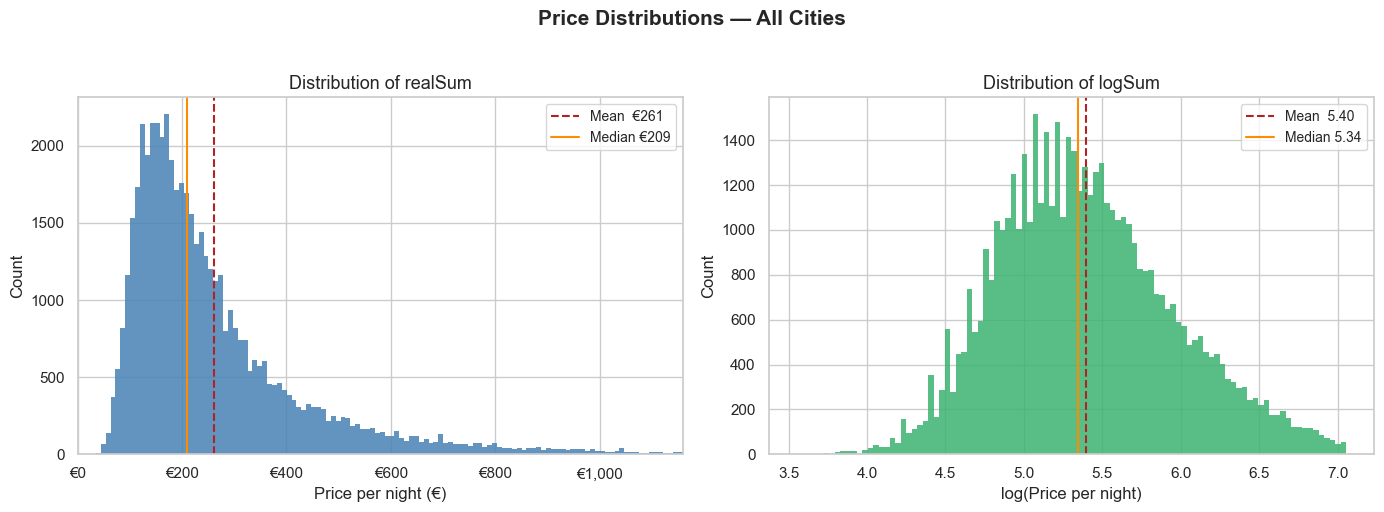

In [24]:
# --- Distribution plots for Prices ---

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')

realSum = df['realSum']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- 1. realSum histogram (right-skewed raw prices) ---
ax = axes[0]
ax.hist(realSum, bins=120, color='steelblue', edgecolor='none', alpha=0.85)
ax.axvline(realSum.mean(),   color='firebrick', lw=1.5, linestyle='--', label=f'Mean  €{realSum.mean():.0f}')
ax.axvline(realSum.median(), color='darkorange', lw=1.5, linestyle='-',  label=f'Median €{realSum.median():.0f}')
ax.set_xlim(0, realSum.max())
ax.set_xlabel('Price per night (€)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Distribution of realSum', fontsize=13)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))
ax.legend(fontsize=10)

# --- 2. logSum histogram (log-transformed) ---
ax = axes[1]
ax.hist(df['logSum'], bins=100, color='mediumseagreen', edgecolor='none', alpha=0.85)
ax.axvline(df['logSum'].mean(),   color='firebrick', lw=1.5, linestyle='--', label=f'Mean  {df["logSum"].mean():.2f}')
ax.axvline(df['logSum'].median(), color='darkorange', lw=1.5, linestyle='-',  label=f'Median {df["logSum"].median():.2f}')
ax.set_xlabel('log(Price per night)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Distribution of logSum', fontsize=13)
ax.legend(fontsize=10)

fig.suptitle('Price Distributions — All Cities', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('dist_overall.png', dpi=300, bbox_inches='tight')
plt.show()


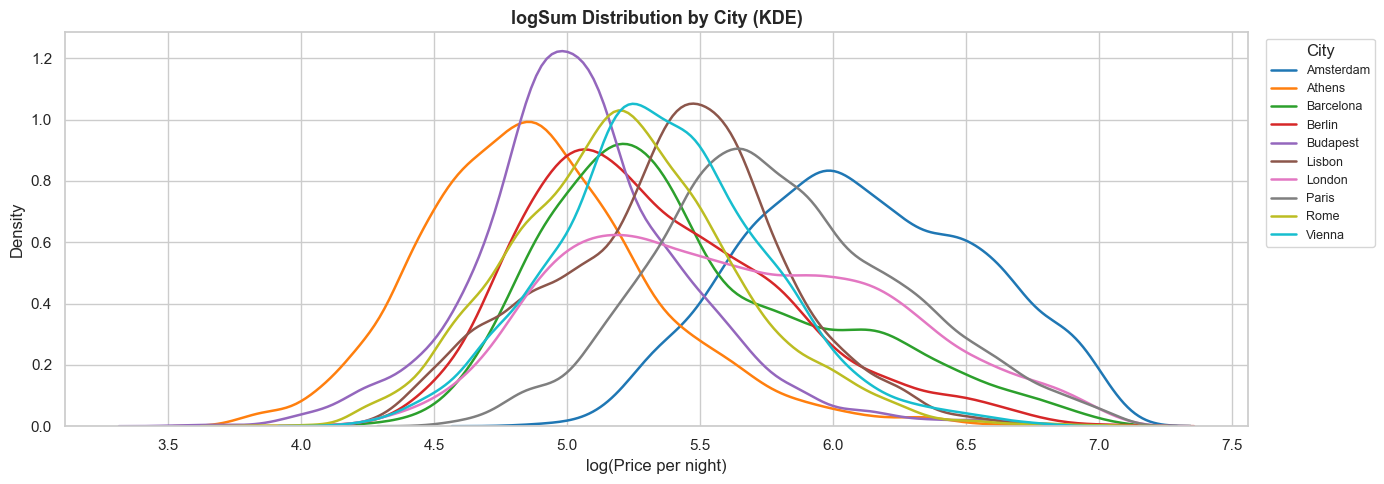

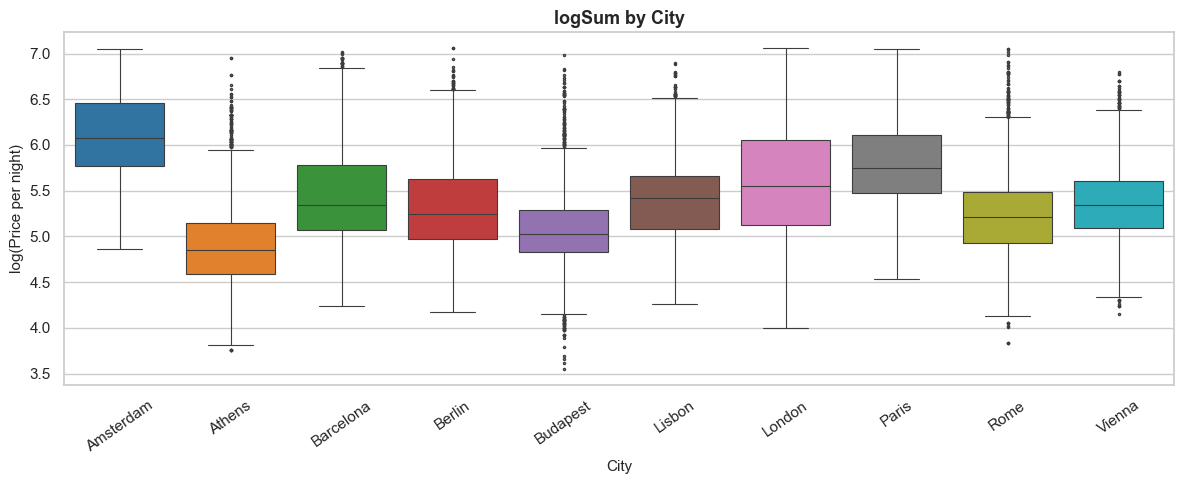

In [9]:
# --- Per-city price distributions ---

city_order = list(CITY_NAMES.values())
city_ids   = list(CITY_NAMES.keys())

# --- 1. Overlapping logSum KDE curves per city ---
fig, ax = plt.subplots(figsize=(14, 5))
palette = sns.color_palette('tab10', n_colors=10)
for city_id, color in zip(city_ids, palette):
    subset = df[df['city'] == city_id]['logSum']
    sns.kdeplot(subset, ax=ax, label=CITY_NAMES[city_id], color=color, linewidth=1.8)
ax.set_xlabel('log(Price per night)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('logSum Distribution by City (KDE)', fontsize=13, fontweight='bold')
ax.legend(title='City', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('dist_logsum_kde_by_city.png', dpi=300, bbox_inches='tight')
plt.show()

# --- 2. logSum box plot per city ---
df['city_name'] = df['city'].map(CITY_NAMES)

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df, x='city_name', y='logSum', order=city_order,
            hue='city_name', hue_order=city_order, palette='tab10',
            legend=False, ax=ax, fliersize=1.5, linewidth=0.8)
ax.set_xlabel('City', fontsize=11)
ax.set_ylabel('log(Price per night)', fontsize=11)
ax.set_title('logSum by City', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.savefig('dist_by_city_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

df.drop(columns=['city_name'], inplace=True)
